## Import des bibliothèques

In [37]:
from math import *
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from PIL import Image
import gzip
import time
from copy import *

### Format d'affichage du temps

In [38]:
def format_time(seconds):
    minutes = int(seconds // 60)
    seconds = int(seconds % 60)
    return f"{minutes} min {seconds} s"

# Projet 15 : Descente de gradient et deeplearning, reconnaissance de chiffres ou lettres manuscrites manuscrites

Ce **réseau de neurones** est composé d'un nombre de couches et de neurones variable. 
en génrale les couches se décomposent de cette manière : 
 - une couche initiale de **784 neurones** qui représentes tous les pixels de l'images en niveau de gris (entre 0 et 1)
 - deux couche cachées d'un **nombre de neurones variable** 
 - une couche de sortie de **10 (digits) ou 47 (balanced) neurones** : l'activation correspond au chiffre entre 0 et 9 ou une lettre majuscule ou minuscule ecris sur l'image

Ce notebook présente **3 types de descente de gradient différentes** : 
 - descente de gradient **classique** sur tout le jeu de donnée à chaque itérations nommée ici ***'Batch'***
 - 2 déscentes de gradient dites **Stochastiques** : 
    - l'une prend des paquets aléatoires de données à chaque itérations, nommée ici ***'mini-batch'***. Cette déscente de gradient implémente le momentum
    - l'une prend une données unique aléatoirement parmis de jeu de données pour chaque itérations, nommée ici ***'stoch'***

## Jeux de données

In [39]:
def lire_image(chemin):
    with gzip.open(chemin, 'rb') as f:
        contenu_fichier = f.read()
        return np.frombuffer(contenu_fichier, dtype=np.uint8, offset=16).reshape(-1,784)/255


def lire_label(chemin):
    with gzip.open(chemin, 'rb') as f:
        contenu_fichier = f.read()
        return np.frombuffer(contenu_fichier, dtype=np.uint8, offset=8)

def choix_dataset(type):    

    '''
    Charge en mémoire la segmentation désirée du dataset EMNIST.
    
    En fonction du choix, le réseau adapte notamment la taille de sa couche de sortie 
    selon le nombre de classes différentes à différencier.
    
    Args :
        type_donnees (str): Choix de la segmentation :
            - 'digits' : Chiffres de 0 à 9 équitablement répartis.
            - 'balanced' : Chiffres de 0 à 9 et lettres (majuscules/minuscules similaires fusionnées).
            - 'bymerge' : Chiffres et lettres non équitablement répartis (plus volumineux).
            - 'letters' : Lettres de 'a' à 'z' (26 classes, majuscules/minuscules confondues).
            
    Returns :
        tuple: Contient 4 éléments :
            - train_dataset (list) : L'intégralité du set d'entraînement.
            - test_dataset (list) : L'intégralité du set de test.
            - sample_erreur (list) : Les 1000 derniers éléments d'entraînement pour le calcul d'erreur rapide.
            - train_reel (list) : Le set d'entraînement allégé des 1000 derniers éléments.
    '''

    if type == 'digits':
        y_train = lire_label('gzip/emnist-digits-train-labels-idx1-ubyte.gz')
        x_train = lire_image('gzip/emnist-digits-train-images-idx3-ubyte.gz')
        x_test = lire_image('gzip/emnist-digits-test-images-idx3-ubyte.gz')
        y_test = lire_label('gzip/emnist-digits-test-labels-idx1-ubyte.gz')
        train_dataset = [[x_train[i], int(y_train[i])] for i in range(len(x_train))]
        test_dataset  = [[x_test[i],  int(y_test[i])]  for i in range(len(x_test))]
        sample_erreur = train_dataset[-1000:]
        train_reel = train_dataset[:-1000]

        return train_dataset, test_dataset, sample_erreur, train_reel

    elif type == 'balanced':
        y_train = lire_label('gzip/emnist-balanced-train-labels-idx1-ubyte.gz')
        x_train = lire_image('gzip/emnist-balanced-train-images-idx3-ubyte.gz')
        x_test = lire_image('gzip/emnist-balanced-test-images-idx3-ubyte.gz')
        y_test = lire_label('gzip/emnist-balanced-test-labels-idx1-ubyte.gz')
        train_dataset = [[x_train[i], int(y_train[i])] for i in range(len(x_train))]
        test_dataset  = [[x_test[i],  int(y_test[i])]  for i in range(len(x_test))]
        sample_erreur = train_dataset[-1000:]
        train_reel = train_dataset[:-1000]

        return train_dataset, test_dataset, sample_erreur, train_reel

    elif type == 'bymerge':
        y_train = lire_label('gzip/emnist-bymerge-train-labels-idx1-ubyte.gz')
        x_train = lire_image('gzip/emnist-bymerge-train-images-idx3-ubyte.gz')
        x_test = lire_image('gzip/emnist-bymerge-test-images-idx3-ubyte.gz')
        y_test = lire_label('gzip/emnist-bymerge-test-labels-idx1-ubyte.gz')
        train_dataset = [[x_train[i], int(y_train[i])] for i in range(len(x_train))]
        test_dataset  = [[x_test[i],  int(y_test[i])]  for i in range(len(x_test))]
        sample_erreur = train_dataset[-1000:]
        train_reel = train_dataset[:-1000]

        return train_dataset, test_dataset, sample_erreur, train_reel

    elif type == 'letters':
        y_train = lire_label('gzip/emnist-letters-train-labels-idx1-ubyte.gz')
        x_train = lire_image('gzip/emnist-letters-train-images-idx3-ubyte.gz')
        x_test = lire_image('gzip/emnist-letters-test-images-idx3-ubyte.gz')
        y_test = lire_label('gzip/emnist-letters-test-labels-idx1-ubyte.gz')
        train_dataset = [[x_train[i], int(y_train[i])-1] for i in range(len(x_train))]
        test_dataset  = [[x_test[i],  int(y_test[i])-1]  for i in range(len(x_test))]
        sample_erreur = train_dataset[-1000:]
        train_reel = train_dataset[:-1000]

        return train_dataset, test_dataset, sample_erreur, train_reel
    
    elif type == 'mnist':
        y_train = lire_label('gzip/emnist-mnist-train-labels-idx1-ubyte.gz')
        x_train = lire_image('gzip/emnist-mnist-train-images-idx3-ubyte.gz')
        x_test = lire_image('gzip/emnist-mnist-test-images-idx3-ubyte.gz')
        y_test = lire_label('gzip/emnist-mnist-test-labels-idx1-ubyte.gz')
        train_dataset = [[x_train[i], int(y_train[i])-1] for i in range(len(x_train))]
        test_dataset  = [[x_test[i],  int(y_test[i])-1]  for i in range(len(x_test))]
        sample_erreur = train_dataset[-1000:]
        train_reel = train_dataset[:-1000]

        return train_dataset, test_dataset, sample_erreur, train_reel

    else : 
        print(f"'{type}' n'est pas dans la liste des datasets")




In [40]:
n_entree = 784
n_mesures = 100 #nombre de points sur la courbe d'apprentissage


## Essaie d'affichage d'un chiffre de la base de donnée MNIST

In [41]:
def classes(dataset):

    if dataset == 'digits':
        with open('gzip/emnist-digits-mapping.txt', 'r') as f:
            correspondance_label_code_str = f.readlines()
        correspondance_label_code = []
        for ligne in correspondance_label_code_str:
            correspondance_label_code.append(list(map(int, ligne.split())))
        n_class = len(correspondance_label_code)
        return n_class, correspondance_label_code

    elif dataset == 'balanced':
        with open('gzip/emnist-balanced-mapping.txt', 'r') as f:
            correspondance_label_code_str = f.readlines()
        correspondance_label_code = []
        for ligne in correspondance_label_code_str:
            correspondance_label_code.append(list(map(int, ligne.split())))
        n_class = len(correspondance_label_code)
        return n_class, correspondance_label_code

    elif dataset == 'bymerge':
        with open('gzip/emnist-bymerge-mapping.txt', 'r') as f:
            correspondance_label_code_str = f.readlines()
        correspondance_label_code = []
        for ligne in correspondance_label_code_str:
            correspondance_label_code.append(list(map(int, ligne.split())))
        n_class = len(correspondance_label_code)
        return n_class, correspondance_label_code

    elif dataset == 'letters':
        with open('gzip/emnist-letters-mapping.txt', 'r') as f:
            correspondance_label_code_str = f.readlines()
            correspondance_label_code = []
        for ligne in correspondance_label_code_str:
            correspondance_label_code.append(list(map(int, ligne.split())))
        n_class = len(correspondance_label_code)
        return n_class, correspondance_label_code
    
    elif dataset == 'mnist':
        with open('gzip/emnist-mnist-mapping.txt', 'r') as f:
            correspondance_label_code_str = f.readlines()
            correspondance_label_code = []
        for ligne in correspondance_label_code_str:
            correspondance_label_code.append(list(map(int, ligne.split())))
        n_class = len(correspondance_label_code)
        return n_class, correspondance_label_code
        
    
def correspondance_label_code(dataset):
    return classes(dataset)[1]

    #print(correspondance_label_code)

def affichage(batch, classe):

    indice = random.randint(0,len(batch))
    plt.imshow(batch[indice][0].reshape(28, 28, order = 'F'), cmap='grey_r') # utilisation de grey_r comme argument de couleur pour avoir les valeurs proches de 1 en noir
    plt.title(f"Label: {chr(correspondance_label_code(classe)[batch[indice][1]][1])}")
    plt.show()

In [85]:
train_dataset = choix_dataset('digits')[0]



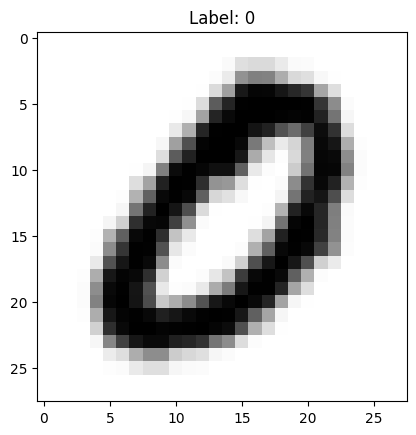

In [86]:
affichage(train_dataset, 'digits')

## initialisation des fonction générales

### Math : fonctions d'activation

In [44]:
def sigmoïde(z):
    """ 
    On définit la fonction sigmoïde en disjonction de cas pour n'utiliser np.exp que dans les négatifs
    Cela évite les explosions de valeurs
    """
    z = np.array(z)
    result = np.empty_like(z, dtype=float)

    pos = z >= 0
    neg = ~pos

    result[pos] = 1 / (1 + np.exp(-z[pos]))
    result[neg] = np.exp(z[neg]) / (1 + np.exp(z[neg]))

    return result

def sigmoïde_prime(z):
    '''
    Dérivée de la fonction d'activation sigmoïde.
    
    Args :
        z (numpy.ndarray): Matrice ou vecteur de la somme pondérée brute.
        
    Returns :
        numpy.ndarray: Matrice de même dimension.
    '''
    s = sigmoïde(z)
    return s * (1 - s)


def relu(z):
    '''
    Fonction d'activation ReLU.
    
    Args :
        z (numpy.ndarray): Matrice ou vecteur de la somme pondérée brute.

    '''
    return np.where(z > 0, z, 0.01 * z)

def relu_prime(z):
    '''
    Dérivée de la fonction d'activation ReLU.
    
    Args :
        z (numpy.ndarray): Matrice ou vecteur de la somme pondérée brute.
        
    Returns :
        numpy.ndarray: Matrice de même dimension contenant 1 pour les valeurs > 0, et 0 sinon.
    '''
    return np.where(z > 0, 1, 0.01)



### Définition du réseau, de la fonction erreur et du gradient

In [45]:
def reseau(poids, m_activations_entree):
    """
    Calcul de la sortie du réseau : l'activation de la première couche du réseau
    entraine l'activation de tous les neurones des couches successives jusqu'à la couche finale
    
    Utilisations de fonctions d'activation : ReLu pour la couche cachée afin d'éviter l'explosion des valeurs et une dérivée qui vaudrait 0 avec la fonction sigmoïde,
    c'est plus optimale pour l'entrainemetn du réseau.
    On utilise la fonction sigmoïde pour la couche rammener les valeurs d'activation entre 0 et 1
    arguments :
        - poids : liste de matrice contenant des matrices array avec les poids des intercouches (couches cachées + couche finale)
        - m_activations_entree : matrice ligne array (taille du batch, ) des listes d'activations (entre 0 et 1) des neurones de la première couche (ligne de 784 activations)


    return :
        - activations : liste de matrices colonnes contenants les activations des couches cachées + couche finale passées dans une fonction d'activation
        - ns : liste de matrices colonnes contenants les activations des couches cachées + couche finale brutes
        - résultat : donne le résultat associé aux activations de la couche finale en fonction de quel neurone est le plus actif
    """

    # 1. Gestion flexible de l'entrée (1 image ou un batch d'images)
    # Si c'est un vecteur 1D (ex: shape (784,)), on le force en matrice colonne (784, 1)
    if len(np.shape(m_activations_entree)) == 1:
        A = np.array(m_activations_entree).reshape(-1, 1)
    else:
        # Si c'est déjà un batch (ex: shape (784, 120)), on le garde tel quel
        A = np.array(m_activations_entree)
    activations = [A]
    ns = []


    W = [p[:, :-1] for p in poids]                  # on extrait les poids situés sur toutes les collonnes sauf la dernière
    B = [p[:, -1].reshape(-1, 1) for p in poids]    # matrice de biais : matrice verticale issue de la dernière colonne d'une matrice de poid

    
    # calcul de l'activation de chaque neurone : produit matriciel

    #couche cachée

    for i in range(len(poids) - 1):
        n = W[i] @ A + B[i]         #activations finale sans ReLu
        A = relu(n)                 
        ns.append(n)
        activations.append(A)

    n = W[-1] @ A + B[-1]          #activations finale sans sigmoïde
    A = sigmoïde(n)                 #activations finale

    ns.append(n)
    activations.append(A)

    # renvoie les indices des activations les plus hautes des couches finales : donc les résultats du réseau pour tous les exemples du batch
    resultat = np.argmax(A, axis=0)

    return activations, ns, resultat



def erreur(poids, batch, n_class):
    """
    Calcul de la distance entre la prédiction du réseau et la vérité attendue.
    fonction erreur globale sur un dataset.
    en effet elle calcul l'erreur unitaire pour une seule donnée et l'ajoute à une
    erreur globale sur tout le dataset choisi

    arguments :
        - poids : liste de matrice contenant des matrices array avec les poids des intercouches (couches cachées + couche finale) ici il y a 1 couche caché donc poids = [W1, W2]
        - list_entrainement : dataset contenant les couples [activation de la couche 0, résultat attendu]

        PS si l'on souhaite avoir réelement l'erreur d'une seule donnée, on importe une base de donnée contenant
        que cette seule donné dans notre fonction erreur

    return :
        - e : sommes des erreurs quadratiques de chaques données du dataset
    """
    a_0 = np.column_stack([image[0] for image in batch])

    n_image = len(batch)                                #nombre de données dans le batch
    
    resultats = np.array([image[1] for image in batch]) #liste array avec les étiquettes des données du batch 
    r = np.zeros((n_class,n_image))  
    r[resultats, np.arange(n_image)] = 1   # matrice qui contient un 1 sur l'indice (ligne) de la bonne réponse de chaques donnée (colonne)

    A_final = reseau(poids, a_0)[0][-1]

    return np.mean((A_final-r)**2) #renvoie l'erreur moyennée sur tout le batch




def obtenir_gradient(poids, batch, n_class):
    '''
    Calcule les matrices de gradient pour toutes les couches de neurones du réseau sur un batch donné.
    
    Cette fonction utilise le principe de la rétropropagation (backpropagation) basé sur la règle 
    de la chaîne pour calculer chaque dérivée partielle. Elle s'adapte dynamiquement au nombre de couches.
    
    Args :
        poids (list): Liste de matrices (arrays) contenant les poids et biais actuels du réseau.
        batch (list): Batch de données contenant les couples [image, label attendu].
        n_class (int): Nombre de classes différentes (taille de la couche de sortie).
        
    Returns :
        list: Liste de matrices contenant l'ajustement des gradients pour chaque couche, 
                dans le même ordre que la liste `poids` en entrée.
    '''

    n_image = len(batch)

    # 1. Préparation des entrées et des étiquettes (targets)
    a_0 = np.column_stack([image[0] for image in batch])
    resultats = np.array([image[1] for image in batch])

    #création d'une liste contenant un 1 sur à l'indice du neurone correspondant au resultat voulu.  
    r = np.zeros((n_class,n_image))
    r[resultats, np.arange(n_image)] = 1

    # 2. Forward pass (on récupère toutes les activations et zs)
    activations, ns, _ = reseau(poids, a_0)
    
    gradients = []

    # 3. Calcul du delta pour la couche de sortie (L)
    # Dérivée de l'erreur quadratique : 2 * (A_final - r)
    # Multiplié par la dérivée de la sigmoïde (dernière couche)
    delta = 2*(activations[-1]-r) * sigmoïde_prime(ns[-1])


    # 4. Rétropropagation (Backpropagation loop)
    # On parcourt les couches de la fin vers le début
    for i in reversed(range(len(poids))): 

        a_prec = activations[i]
        lignes_uns_ai = np.ones((1,n_image))
        a_precedante_biais = np.vstack((a_prec, lignes_uns_ai))
        
        grad = delta @ a_precedante_biais.T
        gradients.append(grad)

        if i > 0:
            # On utilise les poids (sans la colonne de biais) de la couche actuelle
            W_actuel = poids[i][:, :-1]
            # Formule : (W^T * delta) * dérivée_activation(z_précédent)
            # Note : on utilise relu_prime pour les couches cachées
            delta = (W_actuel.T @ delta) * relu_prime(ns[i-1])

    # Comme on a parcouru à l'envers, on remet les gradients dans l'ordre [W1, W2, ...]
    return [gradient_W / n_image for gradient_W in gradients[::-1]]


def initialiser_poids(n_entree, n_cachees, n_class):
    """
    n_cachees : liste du nombre de neurones par couche cachée
                ex: [50] ou [128, 64] ou [] pour aucune couche cachée
    """
    poids = []
    tailles = [n_entree] + n_cachees + [n_class]

    for i in range(len(tailles) - 1):
        n_in  = tailles[i]
        n_out = tailles[i + 1]
        if i < len(tailles) - 2:  # couches cachées → He
            W = np.random.randn(n_out, n_in + 1) * np.sqrt(2 / n_in)
        else:                      # couche sortie → Xavier
            W = np.random.randn(n_out, n_in + 1) * np.sqrt(1 / n_in)
        poids.append(W)

    return poids


### fonctions de test du réseau (une fois celui-ci entrainé)

In [46]:
def try_data(poids, dataset):
    '''
    Teste un réseau de neurones (pré-entraîné) sur un jeu de données annotées.

    Args :
        poids (list): Liste de matrices (arrays) contenant les poids et biais du réseau.
        dataset (list): Liste de couples contenant l'activation initiale (image) et le résultat attendu (label).

    Returns :
        tuple: Contient 3 éléments :
            - succes_rate (float) : Taux de succès sur le dataset (en pourcentage).
            - erreur (list) : Liste des données pour lesquelles le réseau s'est trompé.
            - succes (list) : Liste des données pour lesquelles le réseau a vu juste.
    '''
    
    erreur = []
    succes = []
    for data in dataset:
        resultat = reseau(poids, data[0])[-1]
        if resultat == data[1]:
          succes.append(data)
        else:
          erreur.append(data)

    succes_rate = len(succes)/len(dataset) * 100
    return succes_rate, erreur, succes


## Descente Batch

In [47]:
def descente_batch(poids, list_entrainement, sample_erreur, n_class, pas = 0.1, n_epoch = 40):
    '''
    Optimisation des poids du réseau via la descente de gradient classique (batch complet).
    
    Le gradient est calculé sur l'ensemble du dataset avant chaque mise à jour. (Lent à converger).
    
    Args :
        poids (list): Liste de matrices contenant les poids et biais initiaux de chaque couche.
        list_entrainement (list): Dataset complet utilisé pour l'entraînement.
        sample_erreur (list): Échantillon de données utilisé pour évaluer l'erreur à chaque itération.
        n_class (int): Nombre de classes différentes en sortie.
        pas (float, optionnel): Taux d'apprentissage (learning rate). Par défaut 0.1.
        n_epoch (int, optionnel): Nombre d'époques (passages complets sur le dataset). Par défaut 40.
        
    Returns :
        tuple: Contient 4 éléments :
            - poids (list) : Matrices de poids et biais optimisés après entraînement.
            - historique_erreurs (list) : Évolution de l'erreur calculée sur `sample_erreur`.
            - X (numpy.ndarray) : Axe des abscisses (époques) pour le tracé.
            - duree_entrainement (float) : Temps total de l'entraînement en secondes.
    '''
    start_time = time.time()

    txt = " | ".join([str(np.shape(p)) for p in poids])
    print(f'taille Poids initiaux : {txt}')
    print(f"Taille du dataset sur lequel on s'entraine : {len(list_entrainement)}")
    print(f'pas : {pas}')
    print(f"nombre d'époques : {n_epoch}")

    with tqdm(total=n_epoch, desc = 'Progression') as bar:

        # initialisation de l'historique d'erreur
        historique_erreurs = []

        #old_W1, old_W2, old_W3, old_W4 = W1.copy(), W2.copy(), W3.copy(), W4.copy()

        for epoch in range(n_epoch):

            grads = obtenir_gradient(poids, list_entrainement, n_class)

            for i in range(len(poids)):
                poids[i] -= grads[i] * pas


            historique_erreurs.append(erreur(poids, sample_erreur, n_class))
            bar.update(1)

    end_time = time.time()
    duree_entrainement = end_time - start_time
    X = np.linspace(0, n_epoch, len(historique_erreurs))
    return poids, historique_erreurs, X, duree_entrainement

## Descente mini-batch (sochastique)

### Avec momentum normal

In [48]:
def descente_mini_batch_avec_momentum(poids, list_entrainement, sample_erreur, n_class, pas = 0.01, mu = 0.7, images_par_batch = 120, n_epoch = 20):
    '''
    Optimisation des poids du réseau via descente de gradient par mini-batch avec momentum classique.
    
    Découpe le dataset en petits groupes et met à jour les poids après chaque groupe, 
    en appliquant un terme de momentum pour lisser et accélérer la convergence.
    
    Args :
        poids (list): Liste de matrices contenant les poids et biais initiaux de chaque couche.
        list_entrainement (list): Dataset complet utilisé pour l'entraînement.
        sample_erreur (list): Échantillon de données utilisé pour évaluer l'erreur à intervalles réguliers.
        n_class (int): Nombre de classes différentes en sortie.
        pas (float, optionnel): Taux d'apprentissage (learning rate). Par défaut 0.01.
        mu (float, optionnel): Coefficient de momentum. Par défaut 0.7.
        images_par_batch (int, optionnel): Taille de chaque mini-batch. Par défaut 120.
        n_epoch (int, optionnel): Nombre de passages complets sur le dataset. Par défaut 20.
        
    Returns :
        tuple: Contient 4 éléments :
            - poids (list) : Matrices de poids et biais optimisés après entraînement.
            - historique_erreurs (list) : Évolution de l'erreur calculée sur `sample_erreur`.
            - X (numpy.ndarray) : Axe des abscisses pour le tracé.
            - duree_entrainement (float) : Temps total de l'entraînement en secondes.

    '''
    start_time = time.time()

    txt = " | ".join([str(np.shape(p)) for p in poids])
    print(f'taille Poids initiaux : {txt}')
    print(f"Taille du dataset sur lequel on s'entraine : {len(list_entrainement)}")
    print(f'pas : {pas}')
    print(f"nombre d'époques : {n_epoch}")
    
    W = deepcopy(poids)
    old_W = deepcopy(W)

    nb_batchs_par_epoch = ceil(len(list_entrainement) / images_par_batch)
    total_steps = n_epoch * nb_batchs_par_epoch
    freq = max(1, total_steps // n_mesures)
    step = 0 

    print(f"calcul de l'erreur et incrémentation de la barre toutes les {freq} itérations")

    # 1. INITIALISATION DE L'HISTORIQUE
    historique_erreurs = []


    with tqdm(total=n_mesures, desc = 'Progression') as bar:

        
        for epoch in range(n_epoch):

            # Mélanger les données à chaque nouvelle époque
            random.shuffle(list_entrainement)

            # 2. CORRECTION : Séparation propre des mini-batchs (évite les index hors limites ou listes vides)
            batchs = [list_entrainement[i:i + images_par_batch] for i in range(0, len(list_entrainement), images_par_batch)]


            # Une étape par mini-batch
            for minibatch in batchs: # 2000 itérations
                    
                grads_minibatch = obtenir_gradient(poids, minibatch, n_class)

                # Mise à jour des poids avec momentum
                new_W = []

                for i in range(len(poids)):
                    new_W.append(W[i] + mu*(W[i] - old_W[i]) - grads_minibatch[i] * pas)

                old_W = deepcopy(W)
                W = new_W
                poids = W

                step +=1

                # 3. ENREGISTREMENT : On stocke l'erreur globale actuelle après la mise à jour
                # Cela permet de voir exactement le comportement "bruité" sur le graphique
                 
                if step % freq == 0:
                    #sample = list_entrainement[:1000]
                    historique_erreurs.append(erreur(poids, sample_erreur, n_class))
                    bar.update(1)
                
                

            # 4. SÉCURITÉ : On recalcule le gradient sur tout le set pour la condition d'arrêt
            # (Si on utilise le gradient du dernier mini-batch, l'algo pourrait s'arrêter par hasard)

            # Sécurité anti-boucle infinie (optionnelle mais recommandée pour les démos)
            
        # 5. RETOUR : On renvoie les poids ET la liste des erreurs
        end_time = time.time()
        duree_entrainement = end_time - start_time 
        X = np.linspace(0, n_epoch, len(historique_erreurs))
    return poids, historique_erreurs, X, duree_entrainement

### Avec momentum de Nerestov

In [49]:
def descente_mini_batch_avec_momentum_nerestov(poids, list_entrainement, sample_erreur, n_class, pas = 0.01, mu = 0.7, images_par_batch = 120, n_epoch = 20):
    '''
    Optimisation des poids du réseau via descente de gradient par mini-batch avec momentum de Nesterov.
    
    Similaire au momentum classique, mais calcule le gradient au point "anticipé" (lookahead) 
    pour une convergence souvent plus rapide et plus stable.
    
    Args :
        poids (list): Liste de matrices contenant les poids et biais initiaux de chaque couche.
        list_entrainement (list): Dataset complet utilisé pour l'entraînement.
        sample_erreur (list): Échantillon de données utilisé pour évaluer l'erreur à intervalles réguliers.
        n_class (int): Nombre de classes différentes en sortie.
        pas (float, optionnel): Taux d'apprentissage (learning rate). Par défaut 0.01.
        mu (float, optionnel): Coefficient de momentum. Par défaut 0.7.
        images_par_batch (int, optionnel): Taille de chaque mini-batch. Par défaut 120.
        n_epoch (int, optionnel): Nombre de passages complets sur le dataset. Par défaut 20.
        
    Returns :
        tuple: Contient 4 éléments :
            - poids (list) : Matrices de poids et biais optimisés.
            - historique_erreurs (list) : Évolution de l'erreur calculée sur `sample_erreur`.
            - X (numpy.ndarray) : Axe des abscisses pour le tracé.
            - duree_entrainement (float) : Temps total de l'entraînement en secondes.
    '''
    start_time = time.time()

    txt = " | ".join([str(np.shape(p)) for p in poids])
    print(f'taille Poids initiaux : {txt}')
    print(f"Taille du dataset sur lequel on s'entraine : {len(list_entrainement)}")
    print(f'pas : {pas}')
    print(f"nombre d'époques : {n_epoch}")
    
    W = deepcopy(poids)
    old_W = deepcopy(W)

    nb_batchs_par_epoch = ceil(len(list_entrainement) / images_par_batch)
    total_steps = n_epoch * nb_batchs_par_epoch
    freq = max(1, total_steps // n_mesures)
    step = 0 

    print(f"calcul de l'erreur et incrémentation de la barre toutes les {freq} itérations")

    # 1. INITIALISATION DE L'HISTORIQUE
    historique_erreurs = []

    #nb_batchs_par_epoch = len(list_entrainement) // images_par_batch
    #total_iterations = n_epoch * nb_batchs_par_epoch

    with tqdm(total=n_mesures, desc = 'Progression') as bar:

        for epoch in range(n_epoch):

            # Mélanger les données à chaque nouvelle époque
            random.shuffle(list_entrainement)

            # 2. CORRECTION : Séparation propre des mini-batchs (évite les index hors limites ou listes vides)
            batchs = [list_entrainement[i:i + images_par_batch] for i in range(0, len(list_entrainement), images_par_batch)]


            # Une étape par mini-batch
            for minibatch in batchs: # 2000 itérations

                # --- Nesterov ---

                # 1. Lookahead
                W_lookahead = []
                for i in range(len(poids)):
                    v = mu * (W[i] - old_W[i])
                    W_lookahead.append(W[i] + v)

                # 2. Gradient au point anticipé
                grads_minibatch = obtenir_gradient(W_lookahead, minibatch, n_class)

                # 3. Update
                new_W = []
                for i in range(len(poids)):
                    new_W.append(W[i] + mu*(W[i] - old_W[i]) - pas * grads_minibatch[i])


                old_W = deepcopy(W)
                W = new_W

                poids = deepcopy(W)

                step +=1

                # 3. ENREGISTREMENT : On stocke l'erreur globale actuelle après la mise à jour
                # Cela permet de voir exactement le comportement "bruité" sur le graphique
                 
                if step % freq == 0:
                    #sample = list_entrainement[:1000]
                    historique_erreurs.append(erreur(poids, sample_erreur, n_class))
                    bar.update(1)
                
                

            # 4. SÉCURITÉ : On recalcule le gradient sur tout le set pour la condition d'arrêt
            # (Si on utilise le gradient du dernier mini-batch, l'algo pourrait s'arrêter par hasard)

            # Sécurité anti-boucle infinie (optionnelle mais recommandée pour les démos)
            
        # 5. RETOUR : On renvoie les poids ET la liste des erreurs
        end_time = time.time()
        duree_entrainement = end_time - start_time 
        X = np.linspace(0, n_epoch, len(historique_erreurs))
    return poids, historique_erreurs, X, duree_entrainement

## Descente stochastique pure

In [50]:
def descente_stoch(poids, list_entrainement, sample_erreur, n_class,  pas = 0.001, n_epoch = 3):
    '''
    Optimisation des poids du réseau via la descente de gradient stochastique pure (SGD).
    
    Met à jour les poids après chaque exemple d'entraînement individuel.
    
    Args :
        poids (list): Liste de matrices contenant les poids et biais initiaux.
        list_entrainement (list): Dataset complet utilisé pour l'entraînement.
        sample_erreur (list): Échantillon de données utilisé pour évaluer l'erreur à intervalles réguliers.
        n_class (int): Nombre de classes différentes en sortie.
        pas (float, optionnel): Taux d'apprentissage (learning rate). Par défaut 0.001.
        n_epoch (int, optionnel): Nombre de passages complets sur le dataset. Par défaut 3.
        
    Returns :
        tuple: Contient 4 éléments :
            - poids (list) : Matrices de poids et biais optimisés.
            - historique_erreurs (list) : Évolution de l'erreur calculée sur `sample_erreur`.
            - X (numpy.ndarray) : Axe des abscisses pour le tracé.
            - duree_entrainement (float) : Temps total de l'entraînement en secondes.
    '''
    start_time = time.time()

    txt = " | ".join([str(np.shape(p)) for p in poids])
    print(f'taille Poids initiaux : {txt}')
    print(f"Taille du dataset sur lequel on s'entraine : {len(list_entrainement)}")
    print(f'pas : {pas}')
    print(f"nombre d'époques : {n_epoch}")

    total_steps = n_epoch * len(list_entrainement)
    freq = total_steps // n_mesures
    step = 0 

    print(f"calcul de l'erreur et incrémentation de la barre toutes les {freq} itérations")

    historique_erreurs = []


    with tqdm(total=n_mesures, desc = 'Progression') as bar:

        for epoch in range(n_epoch):
            
            # Mélanger les données à chaque nouvelle époque
            random.shuffle(list_entrainement)

            for (x,y) in list_entrainement:

                grads_unitaires = obtenir_gradient(poids, [(x,y)], n_class)

                # Mise à jour des poids
                for i in range(len(poids)):
                    poids[i] -= grads_unitaires[i] * pas

                step +=1
                
                if step % freq == 0:
                    historique_erreurs.append(erreur(poids, sample_erreur, n_class))
                    bar.update(1)
                
        end_time = time.time()
        duree_entrainement = end_time - start_time
        X = np.linspace(0, n_epoch, len(historique_erreurs))
    return poids, historique_erreurs, X, duree_entrainement

## Test du réseau sur le dataset de test (Choix de la descente de gradient)

### Choix du dataset

In [87]:
dataset = 'digits'

train_dataset, test_dataset, sample_erreur, train_reel = choix_dataset(dataset)
n_class, correspondance = classes(dataset)

print(f"On s'entraine sur le dataset '{dataset}'")

On s'entraine sur le dataset 'digits'


### Choix de la géométrie du reseau

In [88]:
# Nombre de couches et neurones par couches
géométrie = [512, 256]

# Initialisation des poids
poids_initiaux = initialiser_poids(784, géométrie ,n_class)

### Choix des paramètres de l'apprentissage

In [89]:
pas = 0.1
mu_momentum = 0.7
images_par_batch_mini = 120
n_epoch = 20

### Entraînement 

In [90]:
'''
                                                ### ATTENTION ###

Choix de la descente de gradient:
    - descente_batch                            TRES LENTS A CONVERGER : déconseillé
    - descente_mini_avec_momentum               RAPIDE ET TAUX DE SUCCES élevé : optimisé pour les chiffres 'digits'
    - descente_mini_avec_momentum_nerestov      RAPIDE ET TAUX DE SUCCES élevé : optimisé pour les chiffres + lettres 'balanced'
    - descente_stoch                            EXTREMEMENT LENT A ENTRAINER : déconseillé

'''

type_entrainement = 'mini_batch_avec_momentum_nerestov'

if type_entrainement == 'batch':
        
    poids_finaux, hist_e, X, duree_entrainement = descente_batch(deepcopy(poids_initiaux) , train_reel, sample_erreur, n_class, pas, n_epoch)
    taux_succes, echecs, succes = try_data(poids_finaux, test_dataset)

    print(f'Taux de succès du réseau {géométrie} sur le dataset {dataset} via entrainement {type_entrainement} : {taux_succes} %')



if type_entrainement == 'mini_batch_avec_momentum':
        
    poids_finaux, hist_e, X, duree_entrainement = descente_mini_batch_avec_momentum(deepcopy(poids_initiaux) , train_reel, sample_erreur, n_class, pas, mu_momentum, images_par_batch_mini, n_epoch)
    taux_succes, echecs, succes = try_data(poids_finaux, test_dataset)

    print(f'Taux de succès du réseau {géométrie} sur le dataset {dataset} via entrainement {type_entrainement} : {taux_succes} %')



if type_entrainement == 'mini_batch_avec_momentum_nerestov':
    
    poids_finaux, hist_e, X, duree_entrainement = descente_mini_batch_avec_momentum_nerestov(deepcopy(poids_initiaux) , train_reel, sample_erreur, n_class, pas, mu_momentum, images_par_batch_mini, n_epoch)
    taux_succes, echecs, succes = try_data(poids_finaux, test_dataset)

    print(f'Taux de succès du réseau {géométrie} sur le dataset {dataset} via entrainement {type_entrainement} : {taux_succes} %')



if type_entrainement == 'stoch':
        
    poids_finaux, hist_e, X, duree_entrainement = descente_stoch(deepcopy(poids_initiaux) , train_reel, sample_erreur, n_class, pas, n_epoch)
    taux_succes, echecs, succes = try_data(poids_finaux, test_dataset)

    print(f'Taux de succès du réseau {géométrie} sur le dataset {dataset} via entrainement {type_entrainement} : {taux_succes} %')

else:
    print(f'{type_entrainement} non pris en charge par le programme')

taille Poids initiaux : (512, 785) | (256, 513) | (10, 257)
Taille du dataset sur lequel on s'entraine : 239000
pas : 0.1
nombre d'époques : 20
calcul de l'erreur et incrémentation de la barre toutes les 398 itérations


Progression: 100%|██████████| 100/100 [14:42<00:00,  8.82s/it]


Taux de succès du réseau [512, 256] sur le dataset digits via entrainement mini_batch_avec_momentum_nerestov : 99.1625 %
mini_batch_avec_momentum_nerestov non pris en charge par le programme


### Tracé de la courbe d'apprentissage

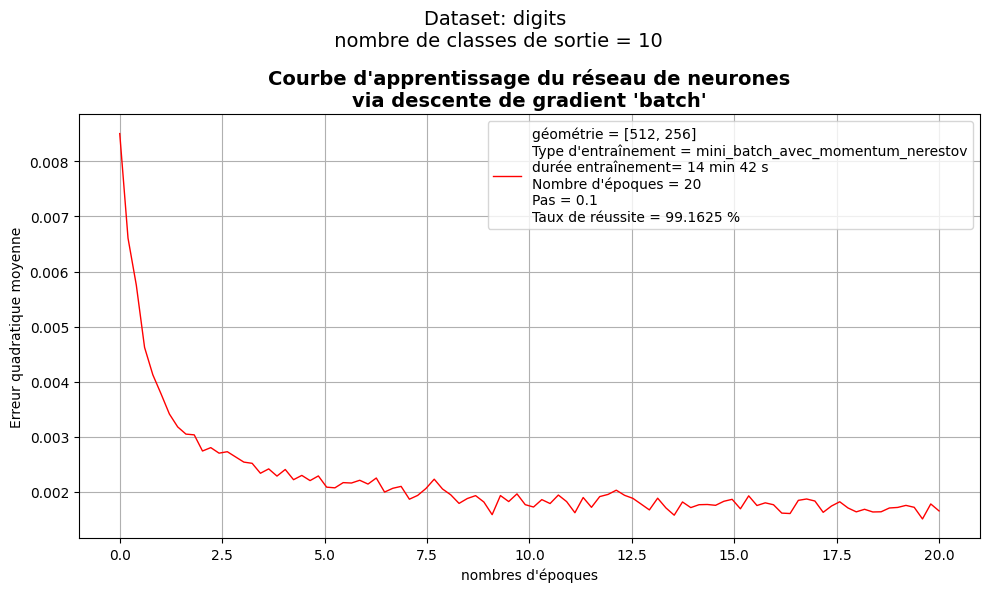

In [91]:
plt.figure(figsize=(10, 6))

# Tracé des trois courbes
 
text = f"géométrie = {géométrie}\nType d'entraînement = {type_entrainement}\ndurée entraînement= {format_time(duree_entrainement)}\nNombre d'époques = {n_epoch}\nPas = {pas}\nTaux de réussite = {taux_succes} %"
    
plt.plot(X, hist_e, label=f'{text}', color='red', alpha=1, linewidth=1)

#abscisse et ordonnée
plt.xlabel("nombres d'époques")
plt.ylabel('Erreur quadratique moyenne')

#titres
plt.title(f"Courbe d'apprentissage du réseau de neurones\nvia descente de gradient 'batch'", fontweight='bold', fontsize=14)
plt.suptitle(f'Dataset: {dataset}\n nombre de classes de sortie = {n_class}', fontsize=14)

#plt.yscale('log')

plt.tight_layout()
plt.legend(loc='upper right'
           #, bbox_to_anchor=(1, 0.85)
           )
plt.grid(True)

plt.show()

### Exemples de succès et erreurs du réseau

Taux de réussite : 99.1625 %
nombre d'erreurs : 39665/40000


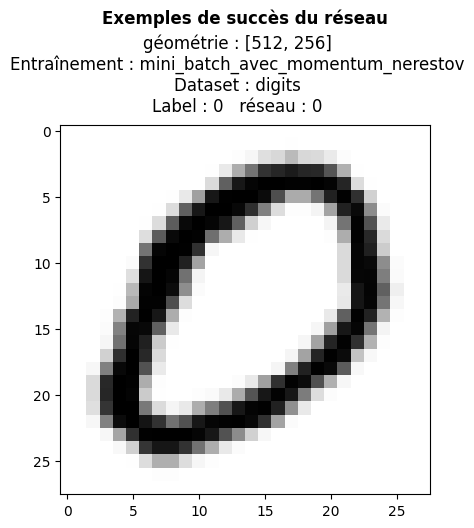

In [92]:
n_succes = len(succes)

print(f'Taux de réussite : {taux_succes} %')
print(f"nombre d'erreurs : {n_succes}/{len(test_dataset)}")

indice = random.randint(0, n_succes)

exemple = succes[indice]
sortie_reseau = int(reseau(poids_finaux, exemple[0])[-1][0])

plt.imshow(exemple[0].reshape(28, 28, order = 'F'), cmap='gray_r')
plt.title(f"Exemples de succès du réseau", fontweight='bold', y=1.25)
plt.suptitle(f"géométrie : {géométrie}\nEntraînement : {type_entrainement}\nDataset : {dataset}\nLabel : {chr(correspondance[exemple[1]][1])}   réseau : {chr(correspondance[sortie_reseau][1])}", y=1.07)
plt.show()

Taux de réussite : 99.1625 %
nombre d'erreurs : 335/40000


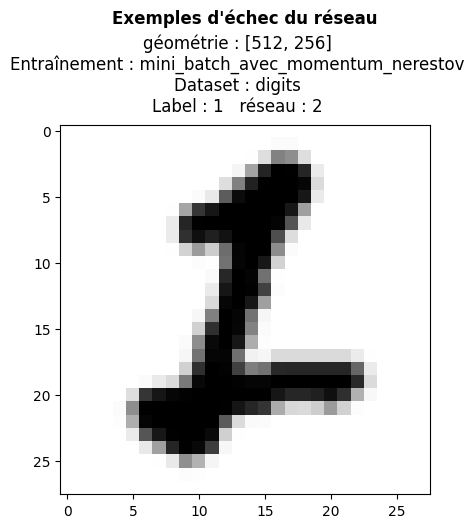

In [93]:
n_echecs = len(echecs)

print(f'Taux de réussite : {taux_succes} %')
print(f"nombre d'erreurs : {n_echecs}/{len(test_dataset)}")

indice = random.randint(0, n_echecs)

exemple = echecs[indice]
sortie_reseau = int(reseau(poids_finaux, exemple[0])[-1][0])

plt.imshow(exemple[0].reshape(28, 28, order = 'F'), cmap='gray_r')
plt.title(f"Exemples d'échec du réseau", fontweight='bold', y=1.25)
plt.suptitle(f"géométrie : {géométrie}\nEntraînement : {type_entrainement}\nDataset : {dataset}\nLabel : {chr(correspondance[exemple[1]][1])}   réseau : {chr(correspondance[sortie_reseau][1])}", y=1.07)
plt.show()

# Scénario :

Vous allez maintenant pouvoir importer une image ou choisir une de celles dessinées par nos soins;

In [58]:
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

### Définition des fonctions

In [59]:
def otsu_maison(img: np.ndarray) -> int:
    """
    Calcule le seuil optimal d'une image en niveaux de gris via la méthode d'Otsu.
    
    Args:
        img (np.ndarray): La matrice de l'intensité des pixels de l'image (niveaux de gris).

    Returns:
        int: Le seuil optimal pour la binarisation.
    """
    # Aplatissement de l'image et calcul de l'histogramme
    hist, _ = np.histogram(img.ravel(), bins=256, range=(0, 256))
    
    # Vectorisation : calcul des sommes cumulées pour chaque seuil possible
    intensites = np.arange(256)
    w_b = np.cumsum(hist)                   # Nombre de pixels dans le fond (Background)
    w_f = img.size - w_b                    # Nombre de pixels dans la forme (Foreground)
    
    # Gestion des divisions par zéro pour les seuils extrêmes
    w_b_safe = np.maximum(w_b, 1)
    w_f_safe = np.maximum(w_f, 1)
    
    # Sommes cumulées des intensités
    sum_b = np.cumsum(hist * intensites)
    sum_total = sum_b[-1]
    
    # Calcul vectorisé des moyennes pour les 256 seuils
    m_b = sum_b / w_b_safe
    m_f = (sum_total - sum_b) / w_f_safe
    
    # Calcul vectorisé de la variance inter-classe
    var_inter = w_b * w_f * (m_b - m_f) ** 2
    
    # Identification des seuils maximisant la variance inter-classe
    seuils_max = np.where(var_inter == var_inter.max())[0]
    seuil_optimal = int(np.mean(seuils_max))
    
    img[:] = np.where(img <= seuil_optimal, 0, 1)
    
    return seuil_optimal

def choisir_rognage(img_test:np.array) -> np.array:
    seuil_initial = 128
    choix = None
    while choix not in ['1', '2', '3']:
        clear_output(True)
        choix = None
        #Rognage grossier (On coupe tout ce qui n'est pas "très sombre")
        img_test1, img_test2, img_test3 = (img_test.copy() for i in [0,1,2])
        img_test1, img_test2, img_test3 = (rogner_gris_selon_intensite(img, seuil_rognage=seuil_initial + 10*i) for (i,img) in enumerate([img_test1, img_test2, img_test3]))

        #Binarisation
        seuil1, seuil2, seuil3 = (otsu_maison(img) for img in [img_test1, img_test2, img_test3]) 

        # Créer une seule fenêtre avec 3 sous-graphiques (1 ligne, 3 colonnes)
        fig, (graphe1, graphe2, graphe3) = plt.subplots(1, 3, figsize=(15, 5))

        # Affichage de chaque image dans son sous-graphique respectif
        graphe1.imshow(img_test1, cmap='gray')
        graphe1.set_title('Choix 1 (Min)')
        graphe1.axis('off')

        graphe2.imshow(img_test2, cmap='gray')
        graphe2.set_title('Choix 2')
        graphe2.axis('off')

        graphe3.imshow(img_test3, cmap='gray')
        graphe3.set_title('Choix 3 (Max)')
        graphe3.axis('off')

        plt.show(block=False)

        # Choix de l'utilisateur
        while choix not in ['1', '2', '3','4','5']:
            choix = input(f'[actuel : {seuil_initial}] Choisissez le seuil préféré (1, 2 ou 3) ou plus(4) ou moins(5) : ')
            if choix == '4':
                seuil_initial += 15
            elif choix == '5':
                seuil_initial -= 15
            plt.close()
        
    choix = int(choix)
    print('Choix :',choix)

    return [img_test1, img_test2, img_test3][choix - 1]

def choisir_rotation(img_choisie:np.array) -> np.array:
    choix = 'non'
    while choix.lower() not in ('oui','o'):
        clear_output(True)
        rotation = None
        while rotation not in ['0', '1', '2', '3']:
            plt.imshow(img_choisie)
            plt.show(block=False)
            rotation = input('Rotation (sens des aiguilles) 0(0), 90(1), 180(2), 270(3) : ')
        plt.close()
        clear_output(True)
        img_choisie = img_choisie.rotate(-[0,90,180,270][int(rotation)])
        plt.imshow(img_choisie)
        plt.show(block=False)
        choix = input('Satisfait ? (oui | o | any) : ')
    plt.close()
    return img_choisie

def rogner_gris_selon_intensite(img: np.ndarray, seuil_rognage: int = 128) -> np.ndarray:
    """
    Rogne une image en niveaux de gris pour encadrer le contenu plus sombre qu'un seuil donné.
    
    Args:
        img (np.ndarray): L'image en niveaux de gris.
        seuil_rognage (int): L'intensité en dessous de laquelle un pixel est considéré comme du contenu (le chiffre).
        
    Returns:
        np.ndarray: L'image rognée. Retourne l'image originale si rien n'est trouvé.
    """
    # Créer un masque booléen : True là où les pixels sont plus sombres que le seuil
    masque_contenu = img < seuil_rognage
    
    # S'il n'y a aucun pixel assez sombre, on retourne l'image telle quelle
    if not np.any(masque_contenu):
        print("Aucun contenu assez sombre trouvé pour le rognage.")
        return img
        
    # Trouver les lignes et les colonnes qui contiennent au moins un pixel sombre
    lignes_avec_contenu = np.any(masque_contenu, axis=1)
    cols_avec_contenu = np.any(masque_contenu, axis=0)
    
    # Trouver les indices de la première et dernière ligne/colonne contenant du contenu
    h = np.argmax(lignes_avec_contenu) # Haut
    b = len(lignes_avec_contenu) - np.argmax(lignes_avec_contenu[::-1]) # Bas
    
    g = np.argmax(cols_avec_contenu) # Gauche
    d = len(cols_avec_contenu) - np.argmax(cols_avec_contenu[::-1]) # Droite
    
    # Rogner et retourner l'image
    marge = 2
    h_marge = max(0, h - marge)
    b_marge = min(img.shape[0], b + marge)
    g_marge = max(0, g - marge)
    d_marge = min(img.shape[1], d + marge)
    
    return img[h_marge:b_marge, g_marge:d_marge]

def rendre_image_carree(img : np.array):
    """
    Prends un image de taille (x,y) et ajoute des lignes vides 
    de chaque coté de la dimension la plus petite jusqu'à ce qu'elle égale l'autre, 
    donnant ainsi une matrice carrée.
    
    Args:
        img (np.array): L'image binarisée en matrice.
    """
    h, w = img.shape
    taille_carré = max(h, w)
    
    # 1. Calcul de la différence à combler pour chaque dimension
    diff_h = taille_carré - h
    diff_w = taille_carré - w
    
    # 2. Répartition de l'ajout de chaque côté (division entière)
    pad_haut = diff_h // 2
    pad_bas = diff_h - pad_haut
    
    pad_gauche = diff_w // 2
    pad_droite = diff_w - pad_gauche
    
    bordure = taille_carré//6
    
    # 3. Application du remplissage (padding)
    img_carree = np.pad(
        img, 
        pad_width=((pad_haut + bordure, pad_bas + bordure), (pad_gauche + bordure, pad_droite + bordure)), 
        mode='constant', 
        constant_values=1
    )
    return img_carree

## Début scénario

### Acquisition

In [60]:
#Ouverture de l'image
img_test = Image.open("images/4.jpeg")
img_test = img_test.convert("L")

#Elle sera tournée c'est normal
img_test.show()

#Lissage (pour atténuer le grain de la photo)
img_test = img_test.filter(ImageFilter.GaussianBlur(radius=1))
img_test = np.array(img_test)

### Rognage

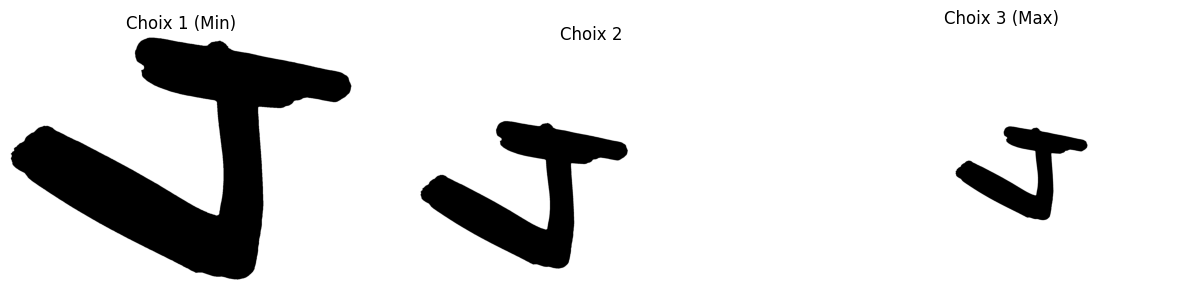

Choix : 1


In [61]:
img_rognee = choisir_rognage(img_test)

### Padding et Rotation

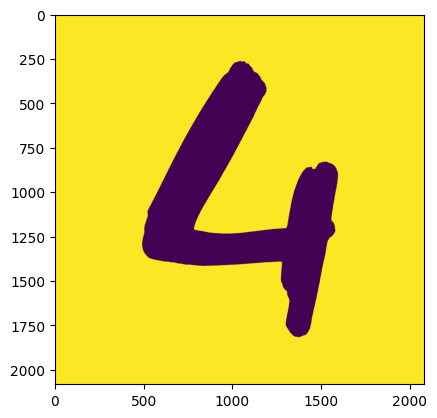

In [62]:
# Traitement sur la bonne image
img_carree = rendre_image_carree(img_rognee)
img_carree = Image.fromarray(img_carree * 255)

#Rotation de l'image
img_tournée = choisir_rotation(img_carree)

### Mise en forme 28x28

TADA !!


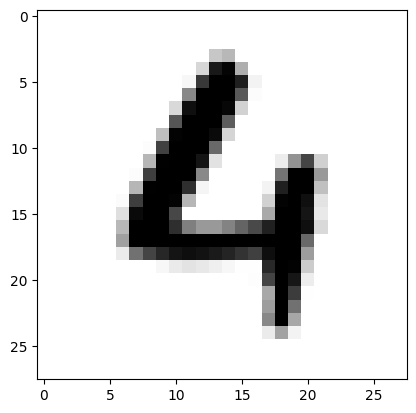

In [94]:
#Création de l'image finale en 28x28
img_finale_pil = img_tournée.resize((28, 28))
plt.imshow(img_finale_pil, cmap='gray')
print('TADA !!')
plt.show()

### Transformation en couche de neurones d'entrée

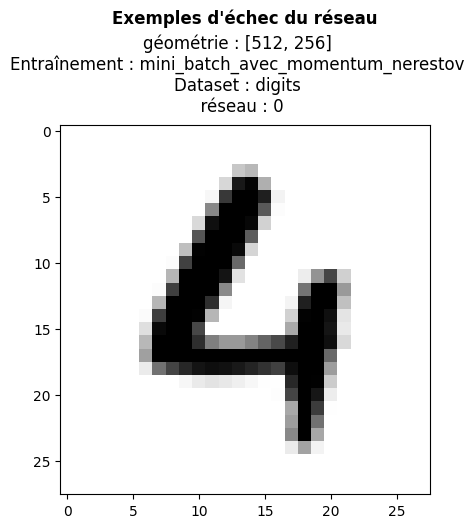

In [95]:
neur_couche_1 = np.array([abs(int(x)-255)/255 for ligne in np.array(img_finale_pil) for x in ligne])

sortie_reseau = reseau(poids_finaux, neur_couche_1)
resultat = int(sortie_reseau[-1][0])

plt.imshow(neur_couche_1.reshape(28, 28), cmap='gray_r')
plt.title(f"Exemples d'échec du réseau", fontweight='bold', y=1.25)
plt.suptitle(f"géométrie : {géométrie}\nEntraînement : {type_entrainement}\nDataset : {dataset}\n  réseau : {chr(correspondance[resultat][1])}", y=1.07)
plt.show()